In [179]:
from pathlib import Path
notebook_dir = Path().resolve()
data_path = notebook_dir.parent / "Finalterm" / "student-mat.csv"
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Microsoft JhengHei'  # or 'Noto Sans TC'
plt.rcParams['axes.unicode_minus'] = False
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [137]:
data = pd.read_csv(data_path).rename(columns={'G3':'FinalGrade'})

data.head(3)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,FinalGrade
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10


In [138]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

| No. | Variable    | 說明 |
|-----|-------------|------|
| 1   | school      | 就讀學校（GP：Gabriel Pereira；MS：Mousinho da Silveira） |
| 2   | sex         | 性別（F：female；M：male） |
| 3   | age         | 年齡（15–22） |
| 4   | address     | 住家型態（U：urban；R：rural） |
| 5   | famsize     | 家庭人數（LE3：≤3；GT3：>3） |
| 6   | Pstatus     | 父母同住狀態（T：together；A：apart） |
| 7   | Medu        | 母親教育程度（0：none；1：primary；2：5–9th；3：secondary；4：higher） |
| 8   | Fedu        | 父親教育程度（0：none；1：primary；2：5–9th；3：secondary；4：higher） |
| 9   | Mjob        | 母親職業（teacher／health／services／at_home／other） |
| 10  | Fjob        | 父親職業（teacher／health／services／at_home／other） |
| 11  | reason      | 選校原因（home／reputation／course／other） |
| 12  | guardian    | 監護人（mother／father／other） |
| 13  | traveltime  | 通學時間（1：<15min；2：15–30；3：30–60；4：>1hr） |
| 14  | studytime   | 每週讀書時間（1：<2hr；2：2–5；3：5–10；4：>10） |
| 15  | failures    | 過去被當次數（1–3；≥3 記為 4） |
| 16  | schoolsup   | 額外教育輔導（yes／no） |
| 17  | famsup      | 家庭教育支持（yes／no） |
| 18  | paid        | 額外付費課程（yes／no） |
| 19  | activities  | 課外活動（yes／no） |
| 20  | nursery     | 是否上過幼兒園（yes／no） |
| 21  | higher      | 是否想讀高等教育（yes／no） |
| 22  | internet    | 家中是否有網路（yes／no） |
| 23  | romantic    | 是否有戀愛關係（yes／no） |
| 24  | famrel      | 家庭關係品質（1–5） |
| 25  | freetime    | 放學後自由時間（1–5） |
| 26  | goout       | 與朋友外出頻率（1–5） |
| 27  | Dalc        | 工作日酒精攝取（1–5） |
| 28  | Walc        | 週末酒精攝取（1–5） |
| 29  | health      | 健康狀況（1–5） |
| 30  | absences    | 缺課次數（0–93） |
| 31  | G1          | 第一階段成績（0–20） |
| 32  | G2          | 第二階段成績（0–20） |
| 33  | G3          | 最終成績（0–20，預測目標） |


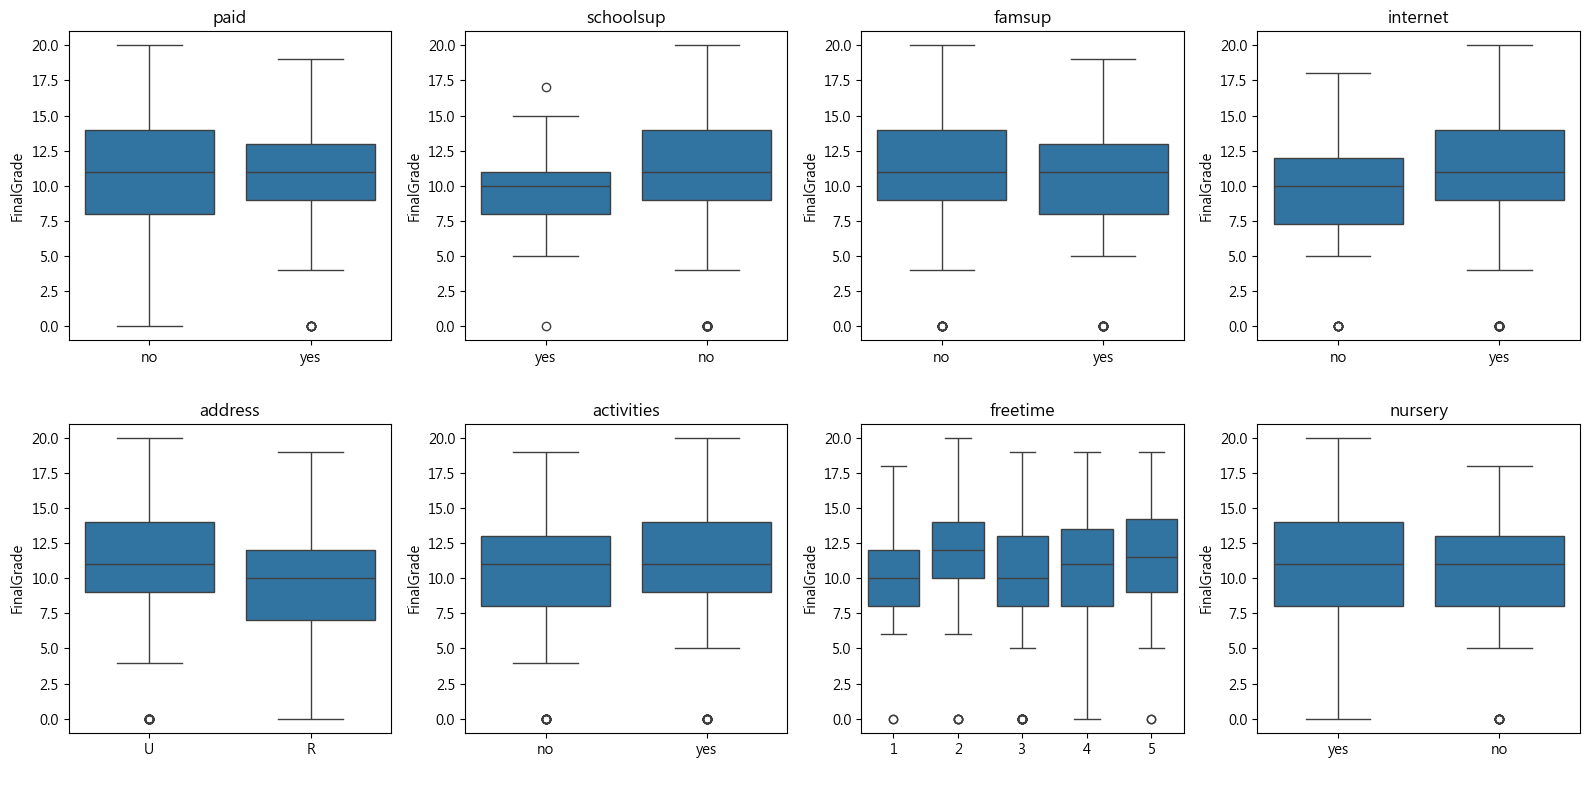

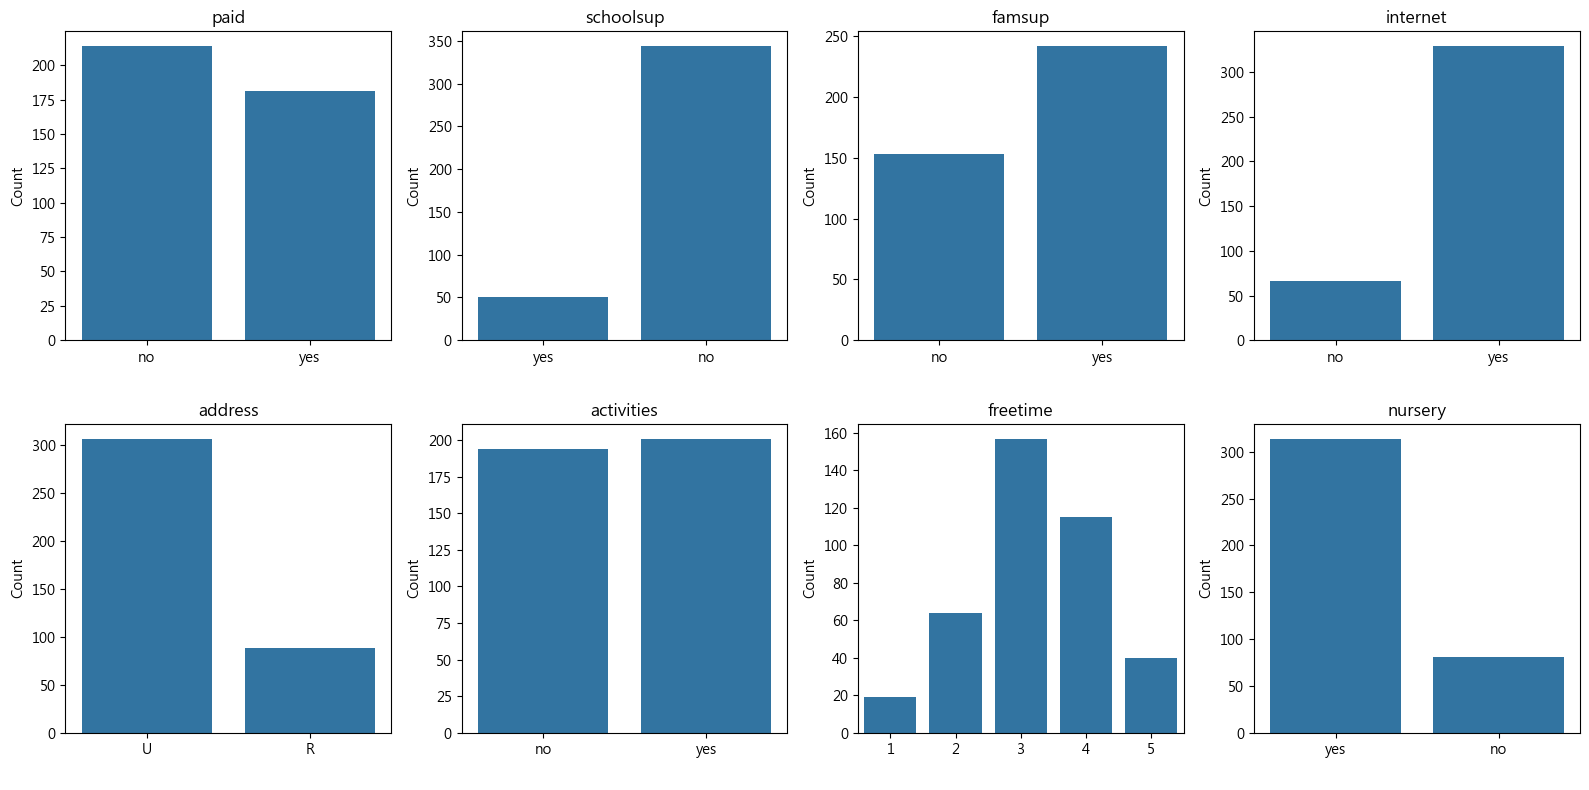

In [182]:

vars_focus = ["paid", "schoolsup", "famsup", "internet",
              "address", "activities", "freetime", "nursery"]

plt.figure(figsize=(16, 8))

for i, var in enumerate(vars_focus, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(x=var, y="FinalGrade", data=data)
    plt.title(var)
    plt.xlabel(" ")
    plt.ylabel("FinalGrade")

plt.tight_layout()
plt.show()

# ---------------------------------------------------
# 2. 2×4 次數長條圖（countplot）
# ---------------------------------------------------
plt.figure(figsize=(16, 8))

for i, var in enumerate(vars_focus, 1):
    plt.subplot(2, 4, i)
    sns.countplot(x=var, data=data)
    plt.title(var)
    plt.xlabel(" ")
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [186]:
# ------------------------------------------
# 1. baseline model 使用的 8 個變項
# ------------------------------------------
vars_baseline = [
    "paid", "schoolsup", "famsup", "internet",
    "address", "activities", "freetime", "nursery"
]

# ------------------------------------------
# 2. 建立 formula：類別變項需用 C() 包起來
# ------------------------------------------
cat_vars = ["paid", "schoolsup", "famsup", "internet",
            "address", "activities", "nursery"]

num_vars = ["freetime"]

formula_terms = []

# 類別變項
for v in cat_vars:
    formula_terms.append(f"C({v})")

# 數值變項
for v in num_vars:
    formula_terms.append(v)

formula_baseline = "FinalGrade ~ " + " + ".join(formula_terms)

print("Baseline formula:")
print(formula_baseline)

# ------------------------------------------
# 3. 擬合 baseline OLS
# ------------------------------------------
model_baseline = smf.ols(formula_baseline, data=data).fit()
print(model_baseline.summary())


Baseline formula:
FinalGrade ~ C(paid) + C(schoolsup) + C(famsup) + C(internet) + C(address) + C(activities) + C(nursery) + freetime
                            OLS Regression Results                            
Dep. Variable:             FinalGrade   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                     1.930
Date:                Fri, 05 Dec 2025   Prob (F-statistic):             0.0543
Time:                        20:19:35   Log-Likelihood:                -1153.4
No. Observations:                 395   AIC:                             2325.
Df Residuals:                     386   BIC:                             2361.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025 

In [187]:
# baseline 資源變項
vars_resource = [
    "paid", "schoolsup", "famsup", "internet",
    "address", "activities", "nursery", "freetime"
]

# 新增的行為變項
vars_behavior = [
    "studytime", "goout", "Dalc", "Walc",
    "absences", "failures", "health", "romantic"
]

# 分類變項（類別型使用 C()）
cat_vars = [
    "paid", "schoolsup", "famsup", "internet",
    "address", "activities", "nursery", "romantic"
]

# 數值變項
num_vars = [
    "freetime", "studytime", "goout", "Dalc",
    "Walc", "absences", "failures", "health"
]

# 建立 formula
terms = []
for v in cat_vars:
    terms.append(f"C({v})")
for v in num_vars:
    terms.append(v)

formula_model2 = "FinalGrade ~ " + " + ".join(terms)

print("Model 2 formula：")
print(formula_model2)

# 擬合模型
model2 = smf.ols(formula_model2, data=data).fit()
print(model2.summary())

Model 2 formula：
FinalGrade ~ C(paid) + C(schoolsup) + C(famsup) + C(internet) + C(address) + C(activities) + C(nursery) + C(romantic) + freetime + studytime + goout + Dalc + Walc + absences + failures + health
                            OLS Regression Results                            
Dep. Variable:             FinalGrade   R-squared:                       0.192
Model:                            OLS   Adj. R-squared:                  0.158
Method:                 Least Squares   F-statistic:                     5.629
Date:                Fri, 05 Dec 2025   Prob (F-statistic):           6.55e-11
Time:                        20:36:01   Log-Likelihood:                -1119.0
No. Observations:                 395   AIC:                             2272.
Df Residuals:                     378   BIC:                             2340.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         

In [188]:
# baseline 資源變項
vars_resource = [
    "paid", "schoolsup", "famsup", "internet",
    "address", "activities", "nursery", "freetime"
]

# 加入的行為變項
vars_behavior = [
    "studytime", "goout", "Dalc", "Walc",
    "absences", "failures", "health", "romantic"
]

# 前期成績
vars_academic = ["G1", "G2"]

# 類別變項（categorical）
cat_vars = [
    "paid", "schoolsup", "famsup", "internet",
    "address", "activities", "nursery", "romantic"
]

# 數值變項（numeric）
num_vars = [
    "freetime", "studytime", "goout", "Dalc",
    "Walc", "absences", "failures", "health",
    "G1", "G2"
]

# 組合變項
terms = []
for v in cat_vars:
    terms.append(f"C({v})")
for v in num_vars:
    terms.append(v)

formula_model4 = "FinalGrade ~ " + " + ".join(terms)

print("Model 4 formula:")
print(formula_model4)

# 擬合模型
model4 = smf.ols(formula_model4, data=data).fit()
print(model4.summary())

Model 4 formula:
FinalGrade ~ C(paid) + C(schoolsup) + C(famsup) + C(internet) + C(address) + C(activities) + C(nursery) + C(romantic) + freetime + studytime + goout + Dalc + Walc + absences + failures + health + G1 + G2
                            OLS Regression Results                            
Dep. Variable:             FinalGrade   R-squared:                       0.836
Model:                            OLS   Adj. R-squared:                  0.828
Method:                 Least Squares   F-statistic:                     106.3
Date:                Fri, 05 Dec 2025   Prob (F-statistic):          3.84e-135
Time:                        20:37:44   Log-Likelihood:                -804.47
No. Observations:                 395   AIC:                             1647.
Df Residuals:                     376   BIC:                             1723.
Df Model:                          18                                         
Covariance Type:            nonrobust                               

In [184]:
num_cols = data.select_dtypes(include=['int64']).columns
cat_cols = data.select_dtypes(include=['object']).columns

<Axes: >

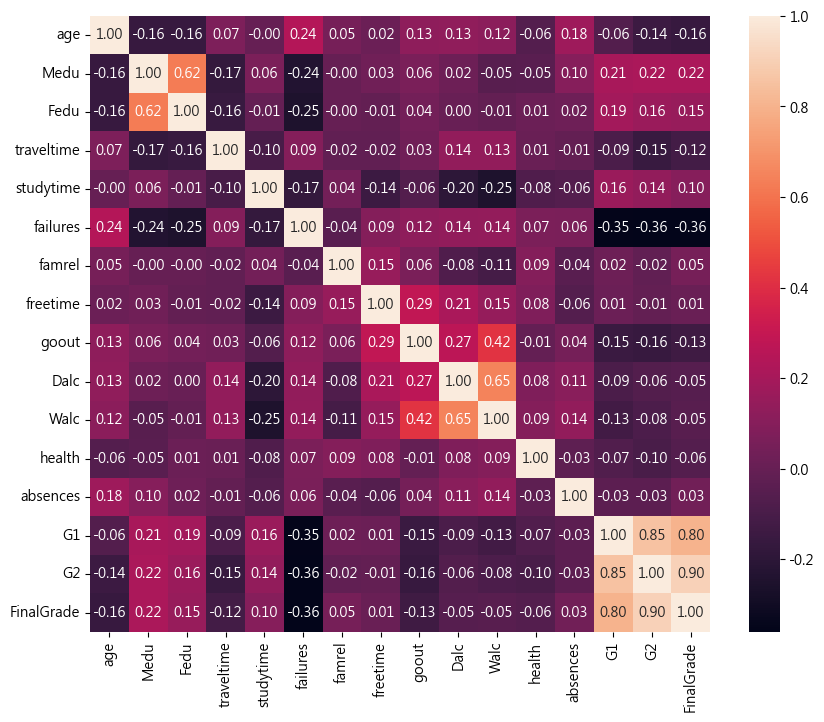

In [185]:
plt.figure(figsize=(10, 8))
sns.heatmap(data=data[num_cols].corr(), fmt='.2f', annot=True)

In [ ]:
scaler = StandardScaler()
num_cols = data.select_dtypes(include=['float64', 'int64']).columns

X = data[num_cols].drop(columns=['FinalGrade'])
X_std = scaler.fit_transform(X)
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_std)
X_pca_df = pd.DataFrame(data=X_pca, index=X.index, columns=[f'PC{i}' for i in range(1, X_pca.shape[1]+1)])
sns.scatterplot(x=X_pca_df['PC1'], y=X_pca_df['PC2'], hue=data['studytime'])